In [55]:
!pip install prophet plotly pandas numpy matplotlib seaborn scikit-learn


In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


In [57]:
data = """District,Ward,Population,Wp,Density(persons per sq km),Df,Area(km2),Avg Education level(Education Index),Ef,Urbanization index(BUA km^2),Uf,Sf,Sm,Days,Total Waste
Colaba/Fort/Navy Nagar,A,210926,0.3,168741,1.2,0622,1.25,0.0059,260.75,0.9,1.85,1.05,91997,190.2,0.1365
Dongri/Masjid Bunder/Umarkhadi/Sandhurst Road,B,199550,0.37,0264,2.8,0792,2.84,0.0003,4160.7,0.88,1.24,1.17,464767,70.2,0.1365
Marine Lines/Dhobi Talao/Kalbadevi,C,170100,0.39,5563,3.5,6686,1.77,0.9996,2330.72,0.888,1.79,1.40,224804,20.2,0.1365
Grant Road/Nana Chowk/Tardeo/Walkeshwar,D,346700,0.34,3175,1.9,9525,8.03,0.11,0017,0.73,0.892,3.37,1.16,786818,60.2,0.1365
Byculla/Mazgaon/Nagpada/Agripada,E,413662,0.35,6500,2.3,957.3,2.14,51327,0.65,0.86,3.87,1.21,143348,90.2,0.1365
Matunga/Sion/Wadala,F/N,698000,0.35,3900,2.3,1712.9,4.99,0724,0.62,0.848,4.62,1.14,270372,50.2,0.1365
Parel/Sewri/Kalachowki,F/S,377873,0.32,7000,1.5,113.99,5.29,63,0.68,0.872,3.49,1.09,974779,90.2,0.1365
Dadar(west)/Mahim/Dharavi,G/N,590609,0.36,5828,2.6,748.48,9.72,0027,95,0.58,0.832,7,1.31,208193,60.2,0.1365
Prabhadevi/Worli/Elphinstone Road,G/S,377749,0.33,7775,1.8,3325,9.99,99735,27,0.6,0.845,5.5,1.22,000058,20.2,0.1365
Bandra(west)/Khar(west)/Santacruz(west),H/W,495000,0.34,2672,1.9,8016,11.6,0011,249,0.7,0.889,1.31,0341,81,80.2,0.1365
Khar(east)/Bandra(east)/Santacruz(East)/Kalina,H/E,579123,0.33,1270,1.6,3811,8.52,0083,15,0.55,0.828,1.17,278540,10.2,0.1365
Chembur East/Govandi/Mankhurd/Trombay,M/E,950000,0.32,9230,1.5,7693,2.5,0085,529,0.35,0.742,0,1.24,614736,80.2,0.1365
Chembur West/Tilak Nagar,M/W,580000,0.32,9940,1.5,9821,9.37,2077,49,0.5,0.812,1.24,777931,0.2,0.1365
Ghatkopar,N,660000,0.32,5423,1.4,6269,25.96,0744,21,0.55,0.821,5,1.23,111818,20.2,0.1365
Andheri East/Jogeshwari East/Vile Parle(east),K/E,1400000,0.39,2000,3.4,615.2,17.39,13,0.6,0.841,4,1.36,8,0.2,0.1365
Andheri West/Jogeshwari West/Vile Parle(west)/Juhu,K/W,750000,0.32,9956,1.5,9868,25.03,672,052,0.65,0.861,2,1.19,171840.2,0.1365
Bhandup/Nahur/Mulund Colony,S,800000,0.32,1164,1.3,3492,37.8,0003,78,0.6,0.843,0,1.31,746,0.2,0.1365
Kurla/Chunabhatti/Nehru Nagar,L,892278,0.35,6189,2.3,8567,15.87,994,091,0.45,0.781,4,1.35,264614,80.2,0.1365"""

# Process the data
lines = data.strip().split('\n')
headers = lines[0].split(',')

# Clean and process data
processed_data = []
for line in lines[1:]:
    # Split by comma but handle potential issues by limiting the split
    # The last column 'Total Waste' seems to have extra commas in some rows.
    # We will split only up to the expected number of columns.
    parts = line.split(',', len(headers) - 1)
    processed_data.append(parts)

# Create DataFrame
df = pd.DataFrame(processed_data, columns=headers)

# Clean numeric columns
numeric_columns = ['Population', 'Density(persons per sq km)', 'Area(km2)',
                   'Avg Education level(Education Index)', 'Urbanization index(BUA km^2)',
                   'Total Waste']

for col in numeric_columns:
    if col in df.columns:
        # Remove any non-numeric characters and convert
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(r'[^\d.]', '', regex=True), errors='coerce')

# Display basic info
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df[['District', 'Population', 'Avg Education level(Education Index)',
         'Urbanization index(BUA km^2)', 'Total Waste']].head())

Dataset shape: (18, 15)

First few rows:
                                        District  Population  \
0                         Colaba/Fort/Navy Nagar      210926   
1  Dongri/Masjid Bunder/Umarkhadi/Sandhurst Road      199550   
2             Marine Lines/Dhobi Talao/Kalbadevi      170100   
3        Grant Road/Nana Chowk/Tardeo/Walkeshwar      346700   
4               Byculla/Mazgaon/Nagpada/Agripada      413662   

   Avg Education level(Education Index)  Urbanization index(BUA km^2)  \
0                                  1.25                        260.75   
1                                  2.84                       4160.70   
2                                  1.77                       2330.72   
3                                  8.03                         17.00   
4                                  2.14                          0.65   

   Total Waste  
0          NaN  
1          NaN  
2          NaN  
3          NaN  
4          NaN  


In [58]:
# Handle missing values and outliers
print("Missing values check:")
print(df.isnull().sum())

# Fill missing values with median for numeric columns
for col in numeric_columns:
    if col in df.columns and df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

# Create a simplified dataset for analysis
analysis_df = df[['District', 'Population', 'Avg Education level(Education Index)',
                 'Urbanization index(BUA km^2)', 'Total Waste']].copy()

# Rename columns for easier handling
analysis_df.columns = ['District', 'Population', 'Education_Index', 'Urbanization_Index', 'Total_Waste']

print("Cleaned dataset:")
print(analysis_df.head())
print(f"\nDataset shape: {analysis_df.shape}")


Missing values check:
District                                 0
Ward                                     0
Population                               0
Wp                                       0
Density(persons per sq km)               0
Df                                       0
Area(km2)                                0
Avg Education level(Education Index)     0
Ef                                       0
Urbanization index(BUA km^2)             0
Uf                                       0
Sf                                       0
Sm                                       0
Days                                     0
Total Waste                             18
dtype: int64
Cleaned dataset:
                                        District  Population  Education_Index  \
0                         Colaba/Fort/Navy Nagar      210926             1.25   
1  Dongri/Masjid Bunder/Umarkhadi/Sandhurst Road      199550             2.84   
2             Marine Lines/Dhobi Talao/Kalbadevi      170100

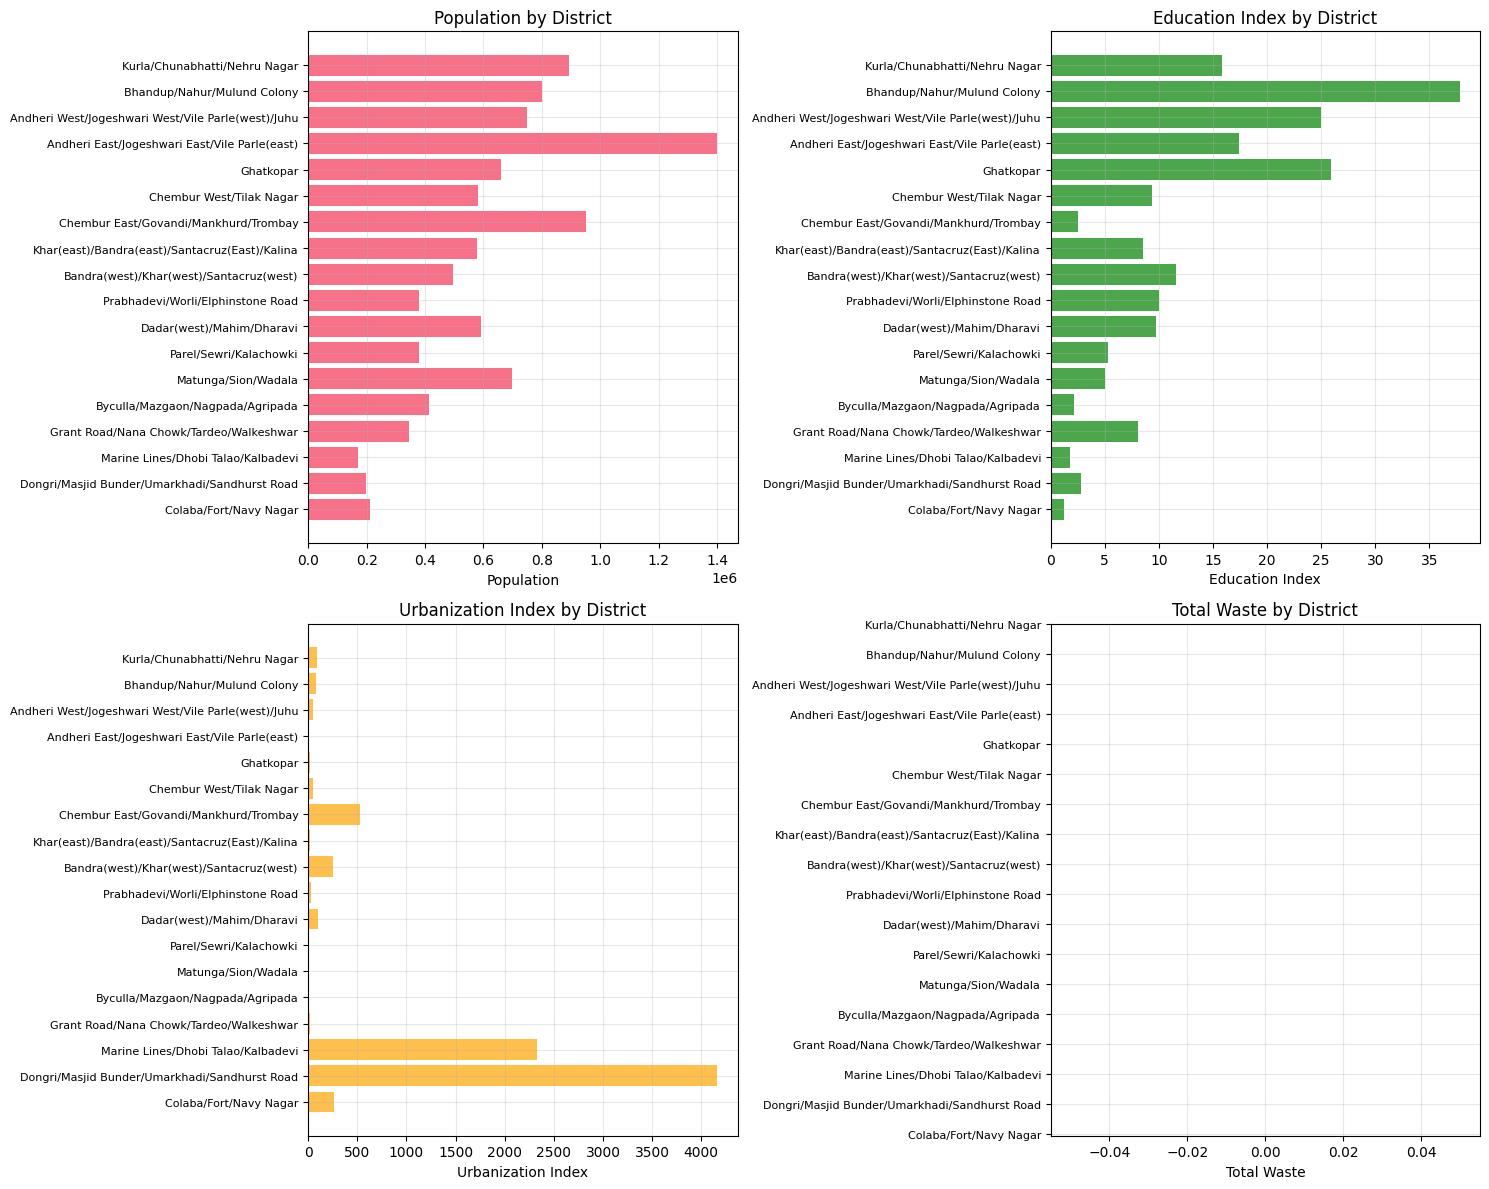

In [59]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Population by District
axes[0,0].barh(range(len(analysis_df)), analysis_df['Population'])
axes[0,0].set_yticks(range(len(analysis_df)))
axes[0,0].set_yticklabels(analysis_df['District'], fontsize=8)
axes[0,0].set_xlabel('Population')
axes[0,0].set_title('Population by District')
axes[0,0].grid(True, alpha=0.3)

# Education Index by District
axes[0,1].barh(range(len(analysis_df)), analysis_df['Education_Index'], color='green', alpha=0.7)
axes[0,1].set_yticks(range(len(analysis_df)))
axes[0,1].set_yticklabels(analysis_df['District'], fontsize=8)
axes[0,1].set_xlabel('Education Index')
axes[0,1].set_title('Education Index by District')
axes[0,1].grid(True, alpha=0.3)

# Urbanization Index by District
axes[1,0].barh(range(len(analysis_df)), analysis_df['Urbanization_Index'], color='orange', alpha=0.7)
axes[1,0].set_yticks(range(len(analysis_df)))
axes[1,0].set_yticklabels(analysis_df['District'], fontsize=8)
axes[1,0].set_xlabel('Urbanization Index')
axes[1,0].set_title('Urbanization Index by District')
axes[1,0].grid(True, alpha=0.3)

# Total Waste by District
axes[1,1].barh(range(len(analysis_df)), analysis_df['Total_Waste'], color='red', alpha=0.7)
axes[1,1].set_yticks(range(len(analysis_df)))
axes[1,1].set_yticklabels(analysis_df['District'], fontsize=8)
axes[1,1].set_xlabel('Total Waste')
axes[1,1].set_title('Total Waste by District')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


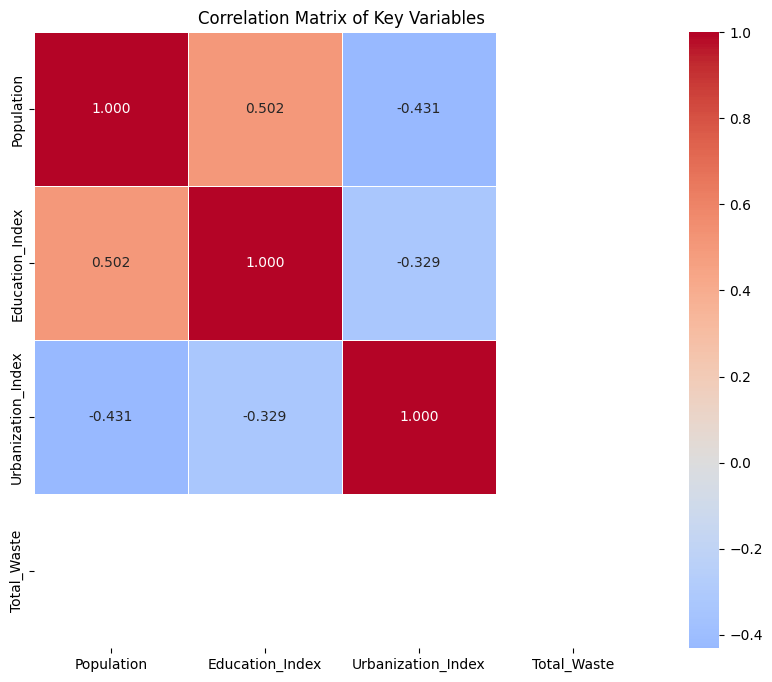

Correlation with Total Waste:
Population           NaN
Education_Index      NaN
Urbanization_Index   NaN
Total_Waste          NaN
Name: Total_Waste, dtype: float64


In [60]:
# Create correlation matrix
correlation_data = analysis_df[['Population', 'Education_Index', 'Urbanization_Index', 'Total_Waste']]
correlation_matrix = correlation_data.corr()

# Plot correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, fmt='.3f')
plt.title('Correlation Matrix of Key Variables')
plt.show()

print("Correlation with Total Waste:")
print(correlation_matrix['Total_Waste'].sort_values(ascending=False))


In [61]:
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Population vs Total Waste', 'Education Index vs Total Waste',
                   'Urbanization Index vs Total Waste', 'All Indexes Comparison'),
    specs=[[{"secondary_y": False}, {"secondary_y": False}],
           [{"secondary_y": False}, {"secondary_y": False}]]
)

# Population vs Total Waste
fig.add_trace(
    go.Scatter(x=analysis_df['Population'], y=analysis_df['Total_Waste'],
               mode='markers+text', text=analysis_df['District'],
               textposition='top center', name='Population vs Waste',
               marker=dict(size=10, color='blue', opacity=0.7)),
    row=1, col=1
)

# Education Index vs Total Waste
fig.add_trace(
    go.Scatter(x=analysis_df['Education_Index'], y=analysis_df['Total_Waste'],
               mode='markers+text', text=analysis_df['District'],
               textposition='top center', name='Education vs Waste',
               marker=dict(size=10, color='green', opacity=0.7)),
    row=1, col=2
)

# Urbanization Index vs Total Waste
fig.add_trace(
    go.Scatter(x=analysis_df['Urbanization_Index'], y=analysis_df['Total_Waste'],
               mode='markers+text', text=analysis_df['District'],
               textposition='top center', name='Urbanization vs Waste',
               marker=dict(size=10, color='orange', opacity=0.7)),
    row=2, col=1
)

# All indexes comparison (3D-like view using bubble chart)
# Handle potential NaN values in 'Total_Waste' before using it for marker size
analysis_df_cleaned = analysis_df.dropna(subset=['Total_Waste']).copy()

if not analysis_df_cleaned.empty:
    fig.add_trace(
        go.Scatter(x=analysis_df_cleaned['Population'], y=analysis_df_cleaned['Education_Index'],
                   mode='markers+text', text=analysis_df_cleaned['District'],
                   textposition='top center', name='Multi-factor Analysis',
                   marker=dict(size=analysis_df_cleaned['Total_Waste']*0.5,
                              color=analysis_df_cleaned['Urbanization_Index'],
                              colorscale='viridis', opacity=0.7,
                              colorbar=dict(title="Urbanization Index"))),
        row=2, col=2
    )
else:
    print("Cannot generate multi-factor analysis plot due to missing 'Total_Waste' data.")


fig.update_layout(height=800, showlegend=False,
                  title_text="Mumbai District Waste Generation Analysis")
fig.show()

Cannot generate multi-factor analysis plot due to missing 'Total_Waste' data.


In [62]:
from datetime import datetime, timedelta
import random

# Set random seed for reproducibility
np.random.seed(42)
random.seed(42)

# Generate synthetic historical data for each district
historical_data = []
start_date = datetime.now() - timedelta(days=730)  # 2 years ago

for idx, row in analysis_df.iterrows():
    district = row['District']
    # Use a default base waste if Total_Waste is NaN in the original data
    base_waste = row['Total_Waste'] if pd.notna(row['Total_Waste']) else 100 # Default value

    # Generate daily data for 2 years
    for day in range(730):
        current_date = start_date + timedelta(days=day)

        # Add seasonal variation (higher in summer, lower in winter)
        seasonal_factor = 1 + 0.2 * np.sin(2 * np.pi * day / 365.25)

        # Add weekly pattern (higher on weekends)
        weekly_factor = 1.1 if current_date.weekday() >= 5 else 1.0

        # Add random noise
        noise_factor = 1 + np.random.normal(0, 0.15)

        # Calculate daily waste
        daily_waste = base_waste * seasonal_factor * weekly_factor * noise_factor

        historical_data.append({
            'ds': current_date,
            'y': daily_waste,
            'district': district,
            'population': row['Population'],
            'education_index': row['Education_Index'],
            'urbanization_index': row['Urbanization_Index']
        })

# Convert to DataFrame
historical_df = pd.DataFrame(historical_data)
print(f"Generated {len(historical_df)} historical data points")
print("Sample data:")
print(historical_df.head())

Generated 13140 historical data points
Sample data:
                          ds           y                district  population  \
0 2023-08-23 18:37:59.322462  107.450712  Colaba/Fort/Navy Nagar      210926   
1 2023-08-24 18:37:59.322462   98.262932  Colaba/Fort/Navy Nagar      210926   
2 2023-08-25 18:37:59.322462  110.470127  Colaba/Fort/Navy Nagar      210926   
3 2023-08-26 18:37:59.322462  136.524112  Colaba/Fort/Navy Nagar      210926   
4 2023-08-27 18:37:59.322462  107.595961  Colaba/Fort/Navy Nagar      210926   

   education_index  urbanization_index  
0             1.25              260.75  
1             1.25              260.75  
2             1.25              260.75  
3             1.25              260.75  
4             1.25              260.75  


In [63]:
from collections import defaultdict

# Store models and forecasts for each district
district_models = {}
district_forecasts = {}

# Train Prophet model for each district
for district in analysis_df['District'].unique():
    print(f"Training model for {district}...")

    # Filter data for current district
    district_data = historical_df[historical_df['district'] == district][['ds', 'y']].copy()

    # Check if there are enough non-NaN values to train the model
    if district_data['y'].notna().sum() < 2:
        print(f"Skipping model training for {district}: Not enough non-NaN data points.")
        continue

    # Create and configure Prophet model
    model = Prophet(
        daily_seasonality=True,
        weekly_seasonality=True,
        yearly_seasonality=True,
        seasonality_mode='multiplicative',
        changepoint_prior_scale=0.05
    )

    # Add custom regressors (population, education, urbanization effects)
    district_info = analysis_df[analysis_df['District'] == district].iloc[0]

    # Fit the model
    model.fit(district_data)

    # Make future dataframe for 6 months (180 days)
    future = model.make_future_dataframe(periods=180, freq='D')

    # Generate forecast
    forecast = model.predict(future)

    # Store model and forecast
    district_models[district] = model
    district_forecasts[district] = forecast

    print(f"✓ Model trained for {district}")

print("All models trained successfully!")

DEBUG:cmdstanpy:input tempfile: /tmp/tmpvhhzdkcs/uw14ewkv.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpvhhzdkcs/c6jazqav.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=76232', 'data', 'file=/tmp/tmpvhhzdkcs/uw14ewkv.json', 'init=/tmp/tmpvhhzdkcs/c6jazqav.json', 'output', 'file=/tmp/tmpvhhzdkcs/prophet_modelg5vt0xb2/prophet_model-20250822183759.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:37:59 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing


Training model for Colaba/Fort/Navy Nagar...


18:37:59 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
DEBUG:cmdstanpy:input tempfile: /tmp/tmpvhhzdkcs/n6uj6srw.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpvhhzdkcs/q6d98yj4.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=47159', 'data', 'file=/tmp/tmpvhhzdkcs/n6uj6srw.json', 'init=/tmp/tmpvhhzdkcs/q6d98yj4.json', 'output', 'file=/tmp/tmpvhhzdkcs/prophet_modeljct2wlw_/prophet_model-20250822183800.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:38:00 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:38:00 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


✓ Model trained for Colaba/Fort/Navy Nagar
Training model for Dongri/Masjid Bunder/Umarkhadi/Sandhurst Road...


DEBUG:cmdstanpy:input tempfile: /tmp/tmpvhhzdkcs/mb9q0m9x.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpvhhzdkcs/n0iik76g.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=97562', 'data', 'file=/tmp/tmpvhhzdkcs/mb9q0m9x.json', 'init=/tmp/tmpvhhzdkcs/n0iik76g.json', 'output', 'file=/tmp/tmpvhhzdkcs/prophet_model_g3lo17l/prophet_model-20250822183800.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:38:00 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:38:00 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


...

✓ Model trained for Andheri West/Jogeshwari West/Vile Parle(west)/Juhu
Training model for Bhandup/Nahur/Mulund Colony...


DEBUG:cmdstanpy:input tempfile: /tmp/tmpvhhzdkcs/y_7bk1zk.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=69693', 'data', 'file=/tmp/tmpvhhzdkcs/wl7prasi.json', 'init=/tmp/tmpvhhzdkcs/y_7bk1zk.json', 'output', 'file=/tmp/tmpvhhzdkcs/prophet_modelxngl2_s_/prophet_model-20250822183809.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:38:09 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:38:10 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
DEBUG:cmdstanpy:input tempfile: /tmp/tmpvhhzdkcs/gm53ugx2.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpvhhzdkcs/5p3pekmo.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.b

✓ Model trained for Bhandup/Nahur/Mulund Colony
Training model for Kurla/Chunabhatti/Nehru Nagar...


18:38:10 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


✓ Model trained for Kurla/Chunabhatti/Nehru Nagar
All models trained successfully!


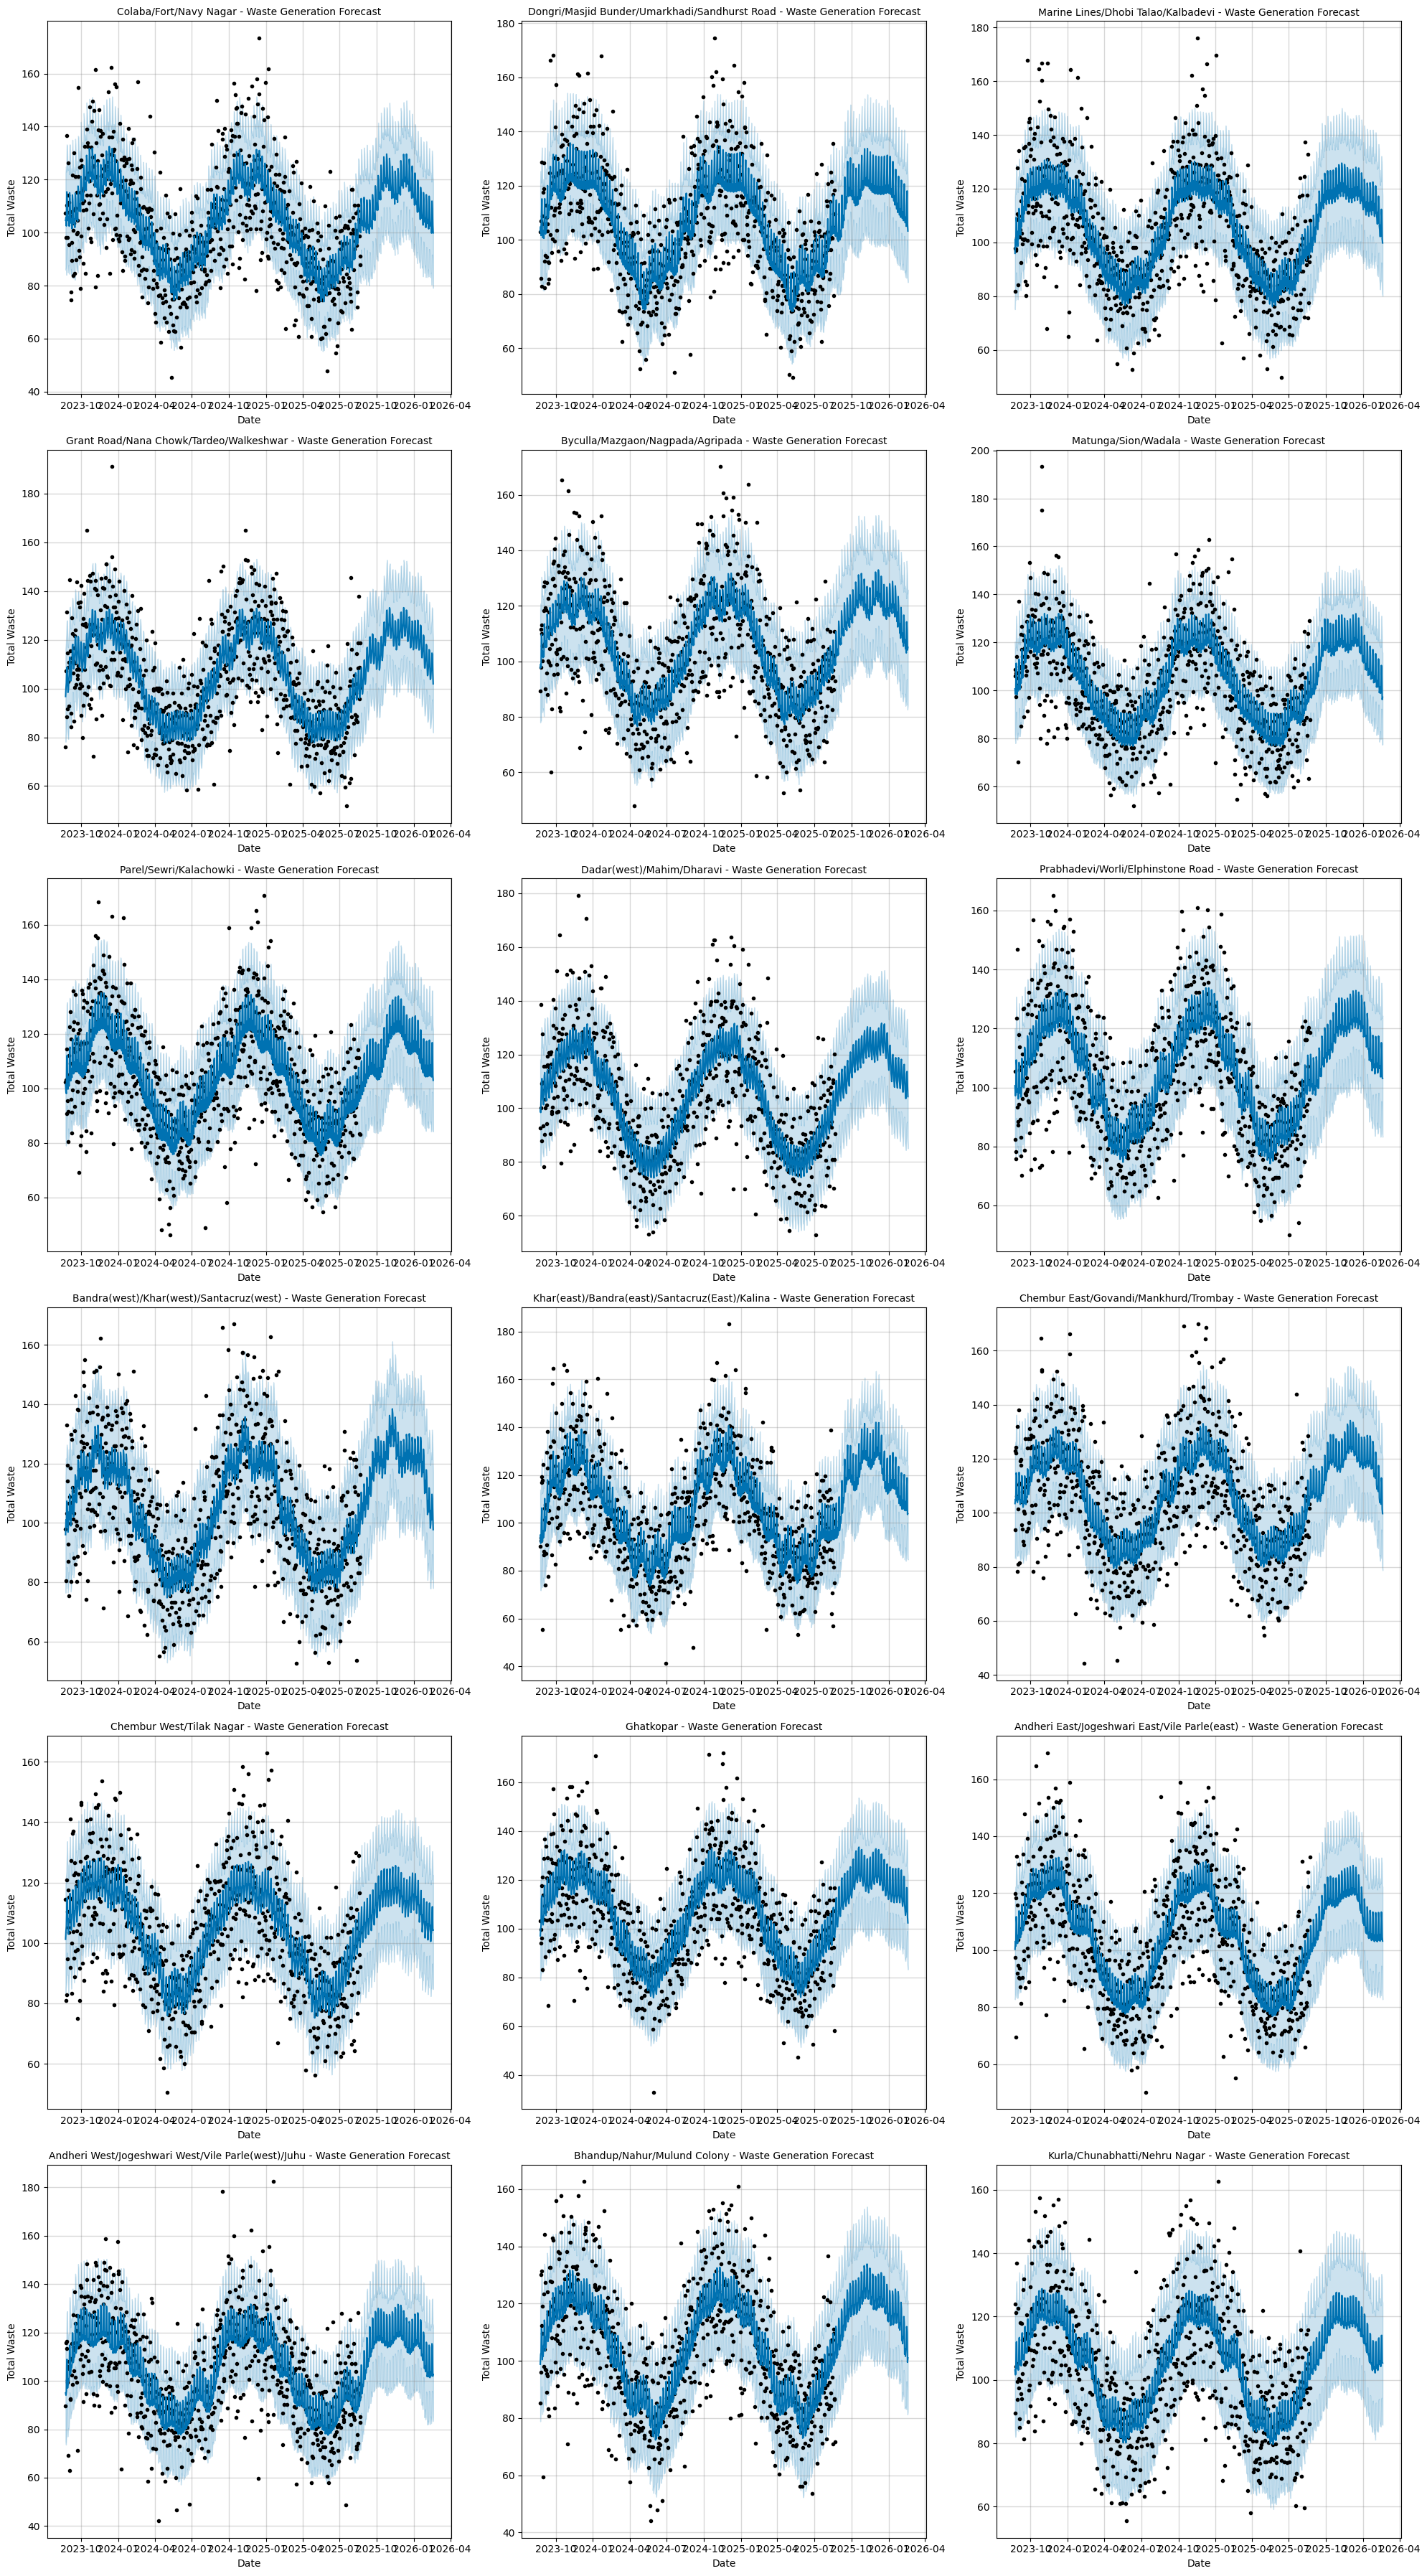

In [64]:
n_districts = len(analysis_df)
cols = 3
rows = (n_districts + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(20, 6*rows))
axes = axes.flatten() if n_districts > 1 else [axes]

for idx, district in enumerate(analysis_df['District'].unique()):
    if idx < len(axes):
        model = district_models[district]
        forecast = district_forecasts[district]

        # Plot forecast
        model.plot(forecast, ax=axes[idx])
        axes[idx].set_title(f'{district} - Waste Generation Forecast', fontsize=10)
        axes[idx].set_xlabel('Date')
        axes[idx].set_ylabel('Total Waste')
        axes[idx].grid(True, alpha=0.3)

# Hide empty subplots
for idx in range(n_districts, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()


DETAILED ANALYSIS FOR COLABA/FORT/NAVY NAGAR


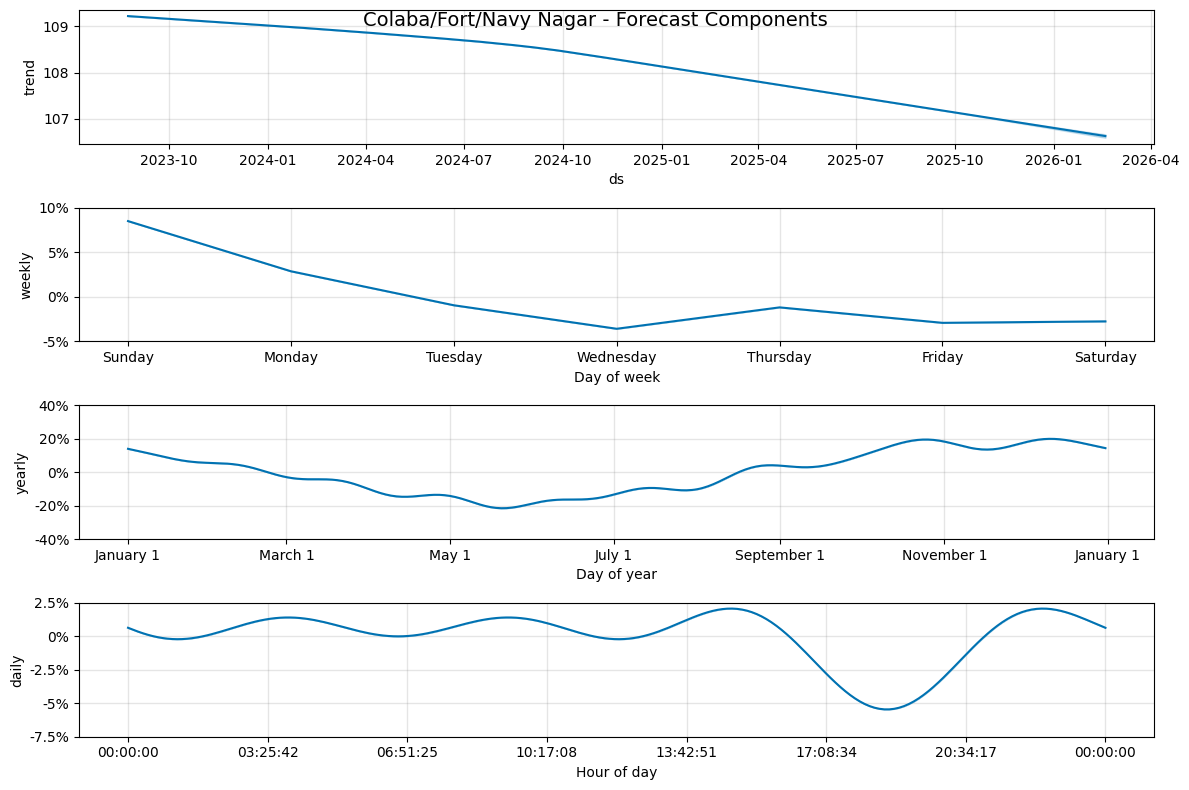

6-Month Forecast Summary for Colaba/Fort/Navy Nagar:
Average daily waste: 113.39
Maximum daily waste: 129.64
Minimum daily waste: 99.69
Total waste (6 months): 20410.98

DETAILED ANALYSIS FOR DONGRI/MASJID BUNDER/UMARKHADI/SANDHURST ROAD


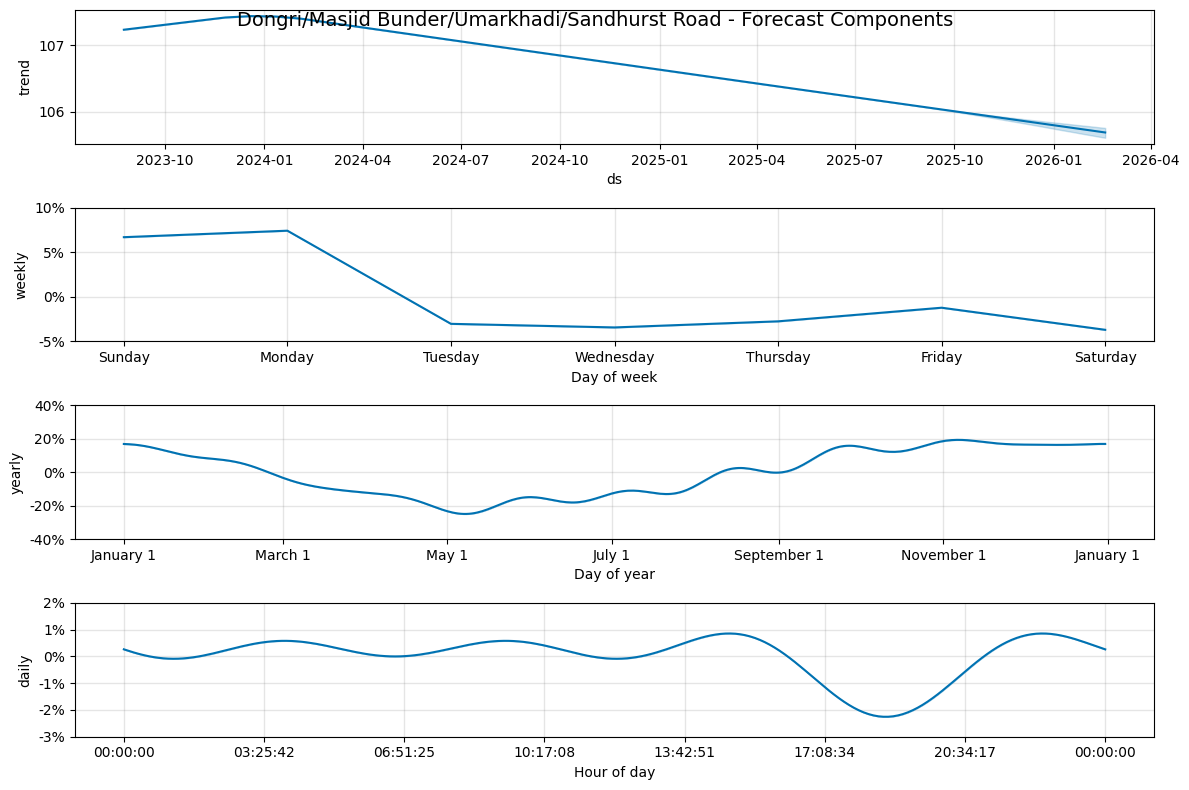

6-Month Forecast Summary for Dongri/Masjid Bunder/Umarkhadi/Sandhurst Road:
Average daily waste: 116.94
Maximum daily waste: 133.74
Minimum daily waste: 99.42
Total waste (6 months): 21049.20

DETAILED ANALYSIS FOR MARINE LINES/DHOBI TALAO/KALBADEVI


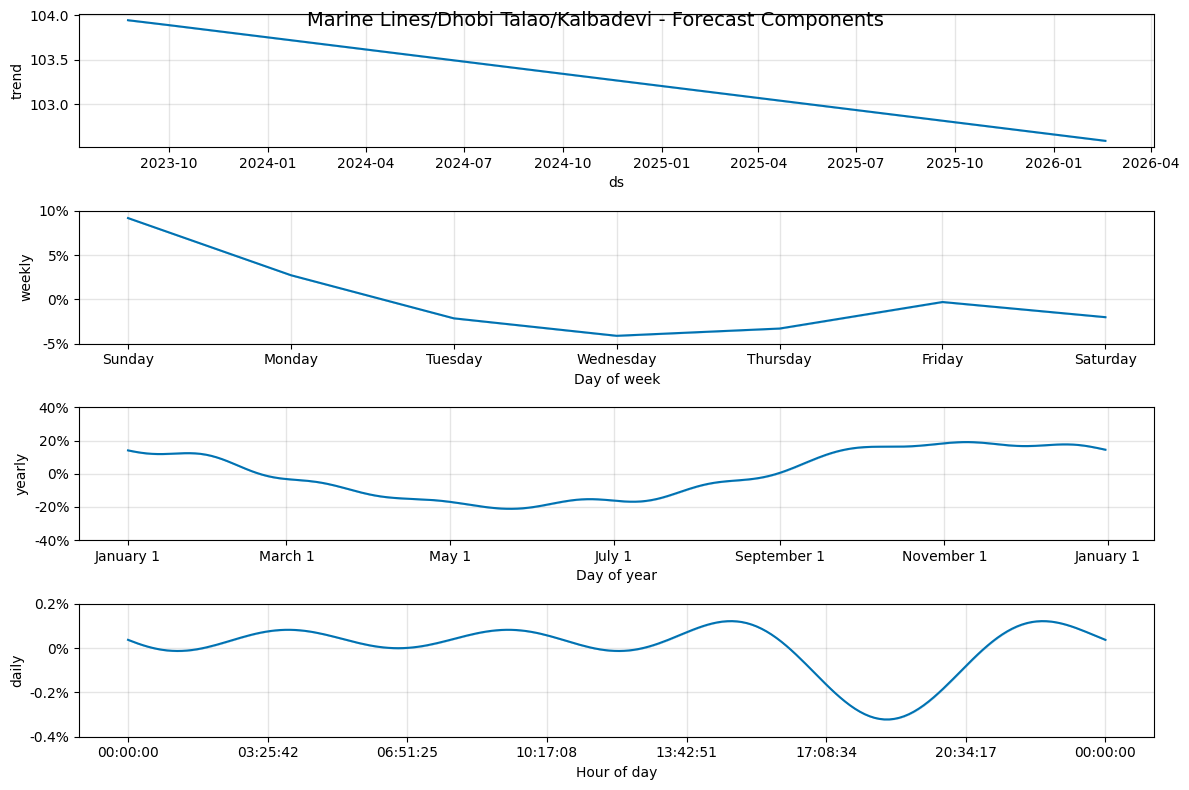

6-Month Forecast Summary for Marine Lines/Dhobi Talao/Kalbadevi:
Average daily waste: 115.75
Maximum daily waste: 129.51
Minimum daily waste: 96.41
Total waste (6 months): 20835.36


In [65]:
top_districts = analysis_df.nlargest(3, 'Total_Waste')['District'].tolist()

for district in top_districts:
    print(f"\n{'='*50}")
    print(f"DETAILED ANALYSIS FOR {district.upper()}")
    print(f"{'='*50}")

    model = district_models[district]
    forecast = district_forecasts[district]

    # Plot components
    fig = model.plot_components(forecast, figsize=(12, 8))
    fig.suptitle(f'{district} - Forecast Components', fontsize=14)
    plt.show()

    # Show forecast statistics
    future_forecast = forecast.tail(180)  # Last 180 days are future predictions

    print(f"6-Month Forecast Summary for {district}:")
    print(f"Average daily waste: {future_forecast['yhat'].mean():.2f}")
    print(f"Maximum daily waste: {future_forecast['yhat'].max():.2f}")
    print(f"Minimum daily waste: {future_forecast['yhat'].min():.2f}")
    print(f"Total waste (6 months): {future_forecast['yhat'].sum():.2f}")


In [71]:
print("Creating interactive district selector with line plots...")

# Create dropdown options
dropdown_buttons = []
for i, district in enumerate(analysis_df['District'].unique()):
    visible_array = [False] * len(analysis_df['District'].unique()) * 3  # 3 traces per district
    visible_array[i*3:(i+1)*3] = [True, True, True]  # Show 3 traces for selected district

    dropdown_buttons.append(
        dict(
            label=district,
            method="update",
            args=[{"visible": visible_array},
                  {"title": f"Waste Generation Forecast - {district}"}]
        )
    )

# Create the interactive line plot
fig_interactive = go.Figure()

# Add line traces for each district
for district in analysis_df['District'].unique():
    forecast = district_forecasts[district]

    # Historical data line
    historical_mask = forecast['ds'] < pd.Timestamp.now()
    fig_interactive.add_trace(
        go.Scatter(
            x=forecast[historical_mask]['ds'],
            y=forecast[historical_mask]['yhat'],
            mode='lines',
            name='Historical Data',
            line=dict(color='#1f77b4', width=2),
            visible=False,
            hovertemplate='<b>Historical</b><br>Date: %{x}<br>Waste: %{y:.1f}<extra></extra>'
        )
    )

    # Future forecast line
    future_mask = forecast['ds'] >= pd.Timestamp.now()
    fig_interactive.add_trace(
        go.Scatter(
            x=forecast[future_mask]['ds'],
            y=forecast[future_mask]['yhat'],
            mode='lines',
            name='6-Month Forecast',
            line=dict(color='#ff7f0e', width=3, dash='solid'),
            visible=False,
            hovertemplate='<b>Forecast</b><br>Date: %{x}<br>Predicted Waste: %{y:.1f}<extra></extra>'
        )
    )

    # Confidence interval (filled area)
    fig_interactive.add_trace(
        go.Scatter(
            x=forecast['ds'].tolist() + forecast['ds'][::-1].tolist(),
            y=forecast['yhat_upper'].tolist() + forecast['yhat_lower'][::-1].tolist(),
            fill='toself',
            fillcolor='rgba(255, 127, 14, 0.2)',
            line=dict(color='rgba(255,255,255,0)'),
            name='Confidence Interval',
            visible=False,
            hoverinfo='skip'
        )
    )

# Make first district visible by default
fig_interactive.data[0].visible = True
fig_interactive.data[1].visible = True
fig_interactive.data[2].visible = True

# Add dropdown menu and styling
fig_interactive.update_layout(
    updatemenus=[
        dict(
            active=0,
            buttons=dropdown_buttons,
            direction="down",
            showactive=True,
            x=0.02,
            xanchor="left",
            y=1.15,
            yanchor="top",
            bgcolor="rgba(255,255,255,0.8)",
            bordercolor="rgba(0,0,0,0.2)",
            borderwidth=1
        ),
    ],
    title={
        'text': f"Interactive Waste Generation Line Plot - {list(analysis_df['District'].unique())[0]}",
        'font': {'size': 16}
    },
    xaxis_title="Date",
    yaxis_title="Daily Waste Generation",
    height=600,
    showlegend=True,
    hovermode='x unified',
    plot_bgcolor='white',
    paper_bgcolor='white'
)

# Add grid lines
fig_interactive.update_xaxes(showgrid=True, gridwidth=1, gridcolor='lightgray')
fig_interactive.update_yaxes(showgrid=True, gridwidth=1, gridcolor='lightgray')

fig_interactive.show()

Creating interactive district selector with line plots...


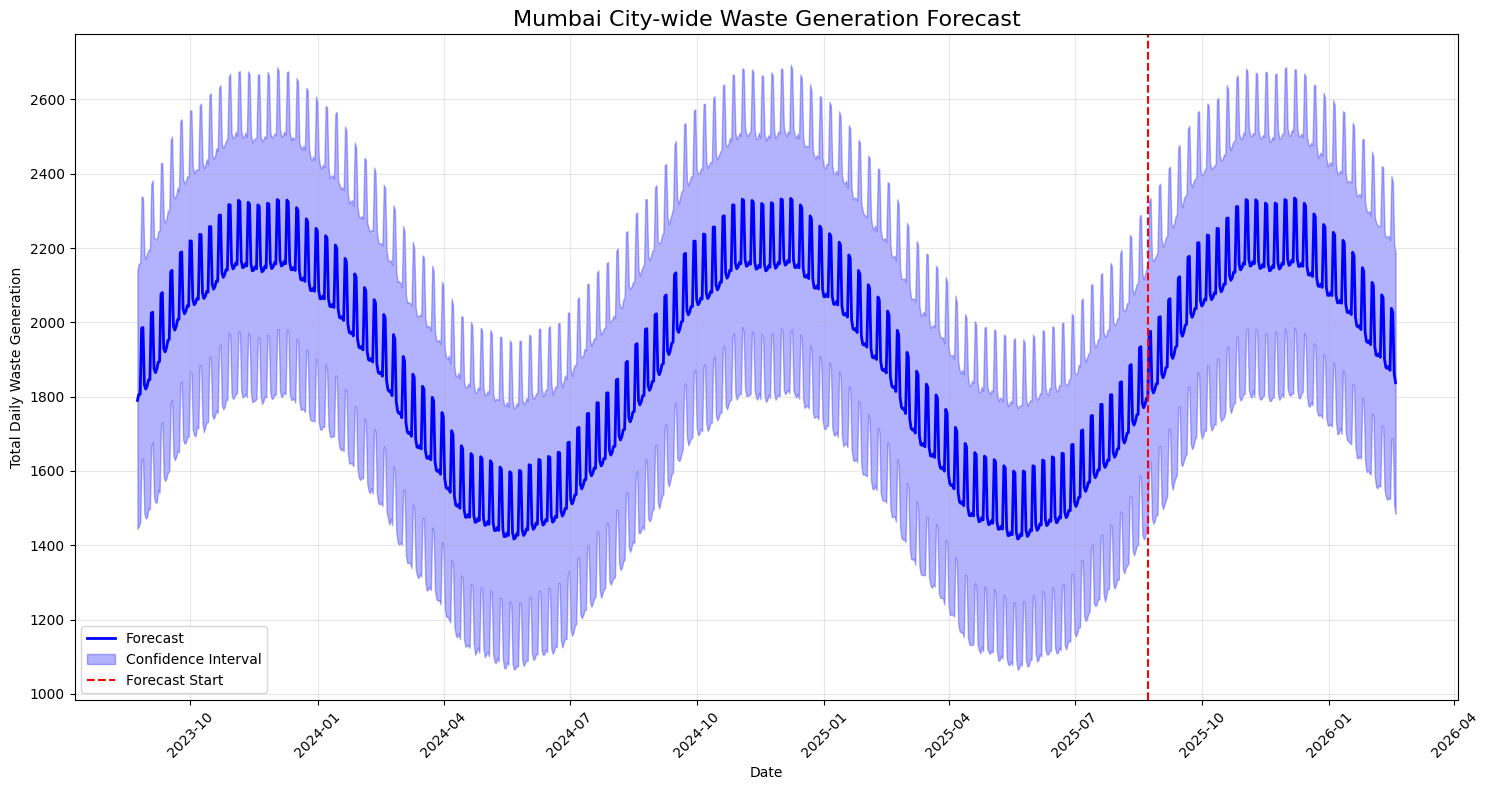


MUMBAI CITY-WIDE 6-MONTH FORECAST SUMMARY:
Average daily waste generation: 2092.44
Maximum daily waste generation: 2334.91
Minimum daily waste generation: 1809.83
Total waste generation (6 months): 374547.48


In [66]:
combined_forecast = pd.DataFrame()

for district in analysis_df['District'].unique():
    forecast = district_forecasts[district]
    district_forecast = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
    district_forecast['district'] = district
    combined_forecast = pd.concat([combined_forecast, district_forecast])

# Aggregate by date
city_forecast = combined_forecast.groupby('ds').agg({
    'yhat': 'sum',
    'yhat_lower': 'sum',
    'yhat_upper': 'sum'
}).reset_index()

# Plot city-wide forecast
plt.figure(figsize=(15, 8))
plt.plot(city_forecast['ds'], city_forecast['yhat'], label='Forecast', color='blue', linewidth=2)
plt.fill_between(city_forecast['ds'], city_forecast['yhat_lower'],
                city_forecast['yhat_upper'], alpha=0.3, color='blue', label='Confidence Interval')

# Mark future predictions
future_start = datetime.now()
plt.axvline(x=future_start, color='red', linestyle='--', label='Forecast Start')

plt.title('Mumbai City-wide Waste Generation Forecast', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Total Daily Waste Generation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Future 6-month statistics
future_city_forecast = city_forecast[city_forecast['ds'] >= future_start]
print(f"\nMUMBAI CITY-WIDE 6-MONTH FORECAST SUMMARY:")
print(f"{'='*50}")
print(f"Average daily waste generation: {future_city_forecast['yhat'].mean():.2f}")
print(f"Maximum daily waste generation: {future_city_forecast['yhat'].max():.2f}")
print(f"Minimum daily waste generation: {future_city_forecast['yhat'].min():.2f}")
print(f"Total waste generation (6 months): {future_city_forecast['yhat'].sum():.2f}")


In [67]:
detailed_export = pd.DataFrame()

for district in analysis_df['District'].unique():
    forecast = district_forecasts[district]
    district_info = analysis_df[analysis_df['District'] == district].iloc[0]

    # Get future forecasts only
    future_forecast = forecast[forecast['ds'] >= datetime.now()].copy()
    future_forecast['district'] = district
    future_forecast['population'] = district_info['Population']
    future_forecast['education_index'] = district_info['Education_Index']
    future_forecast['urbanization_index'] = district_info['Urbanization_Index']

    detailed_export = pd.concat([detailed_export, future_forecast])

# Select relevant columns for export
export_columns = ['ds', 'district', 'yhat', 'yhat_lower', 'yhat_upper',
                 'population', 'education_index', 'urbanization_index']
detailed_export = detailed_export[export_columns]
detailed_export.columns = ['Date', 'District', 'Predicted_Waste', 'Lower_Bound',
                          'Upper_Bound', 'Population', 'Education_Index', 'Urbanization_Index']

# Save to CSV
detailed_export.to_csv('mumbai_waste_forecast_6months.csv', index=False)
print("Detailed forecast exported to 'mumbai_waste_forecast_6months.csv'")

# Show summary
print(f"\nExport Summary:")
print(f"Total rows: {len(detailed_export)}")
print(f"Date range: {detailed_export['Date'].min()} to {detailed_export['Date'].max()}")
print(f"Districts covered: {detailed_export['District'].nunique()}")

print("\nFirst few rows of export:")
print(detailed_export.head())


Detailed forecast exported to 'mumbai_waste_forecast_6months.csv'

Export Summary:
Total rows: 3222
Date range: 2025-08-23 18:37:59.322462 to 2026-02-17 18:37:59.322462
Districts covered: 18

First few rows of export:
                          Date                District  Predicted_Waste  \
731 2025-08-23 18:37:59.322462  Colaba/Fort/Navy Nagar       112.872732   
732 2025-08-24 18:37:59.322462  Colaba/Fort/Navy Nagar       110.781608   
733 2025-08-25 18:37:59.322462  Colaba/Fort/Navy Nagar       104.972901   
734 2025-08-26 18:37:59.322462  Colaba/Fort/Navy Nagar       102.648327   
735 2025-08-27 18:37:59.322462  Colaba/Fort/Navy Nagar       103.468804   

     Lower_Bound  Upper_Bound  Population  Education_Index  Urbanization_Index  
731    93.567226   131.452776      210926             1.25              260.75  
732    90.903712   129.166945      210926             1.25              260.75  
733    87.313024   124.045054      210926             1.25              260.75  
734    

MODEL PERFORMANCE METRICS:
                                          District    MAE   RMSE    R²  MAPE (%)
                            Colaba/Fort/Navy Nagar 11.795 15.044 0.491    11.986
     Dongri/Masjid Bunder/Umarkhadi/Sandhurst Road 11.969 15.061 0.526    11.928
                Marine Lines/Dhobi Talao/Kalbadevi 11.800 15.372 0.498    11.978
           Grant Road/Nana Chowk/Tardeo/Walkeshwar 11.975 14.996 0.534    12.089
                  Byculla/Mazgaon/Nagpada/Agripada 12.570 15.845 0.473    12.938
                               Matunga/Sion/Wadala 11.864 15.284 0.504    12.388
                            Parel/Sewri/Kalachowki 11.857 14.949 0.505    12.271
                         Dadar(west)/Mahim/Dharavi 11.725 15.139 0.534    11.930
                 Prabhadevi/Worli/Elphinstone Road 12.495 15.662 0.505    12.776
           Bandra(west)/Khar(west)/Santacruz(west) 12.828 16.146 0.481    13.159
    Khar(east)/Bandra(east)/Santacruz(East)/Kalina 12.251 15.575 0.529    12.564
 

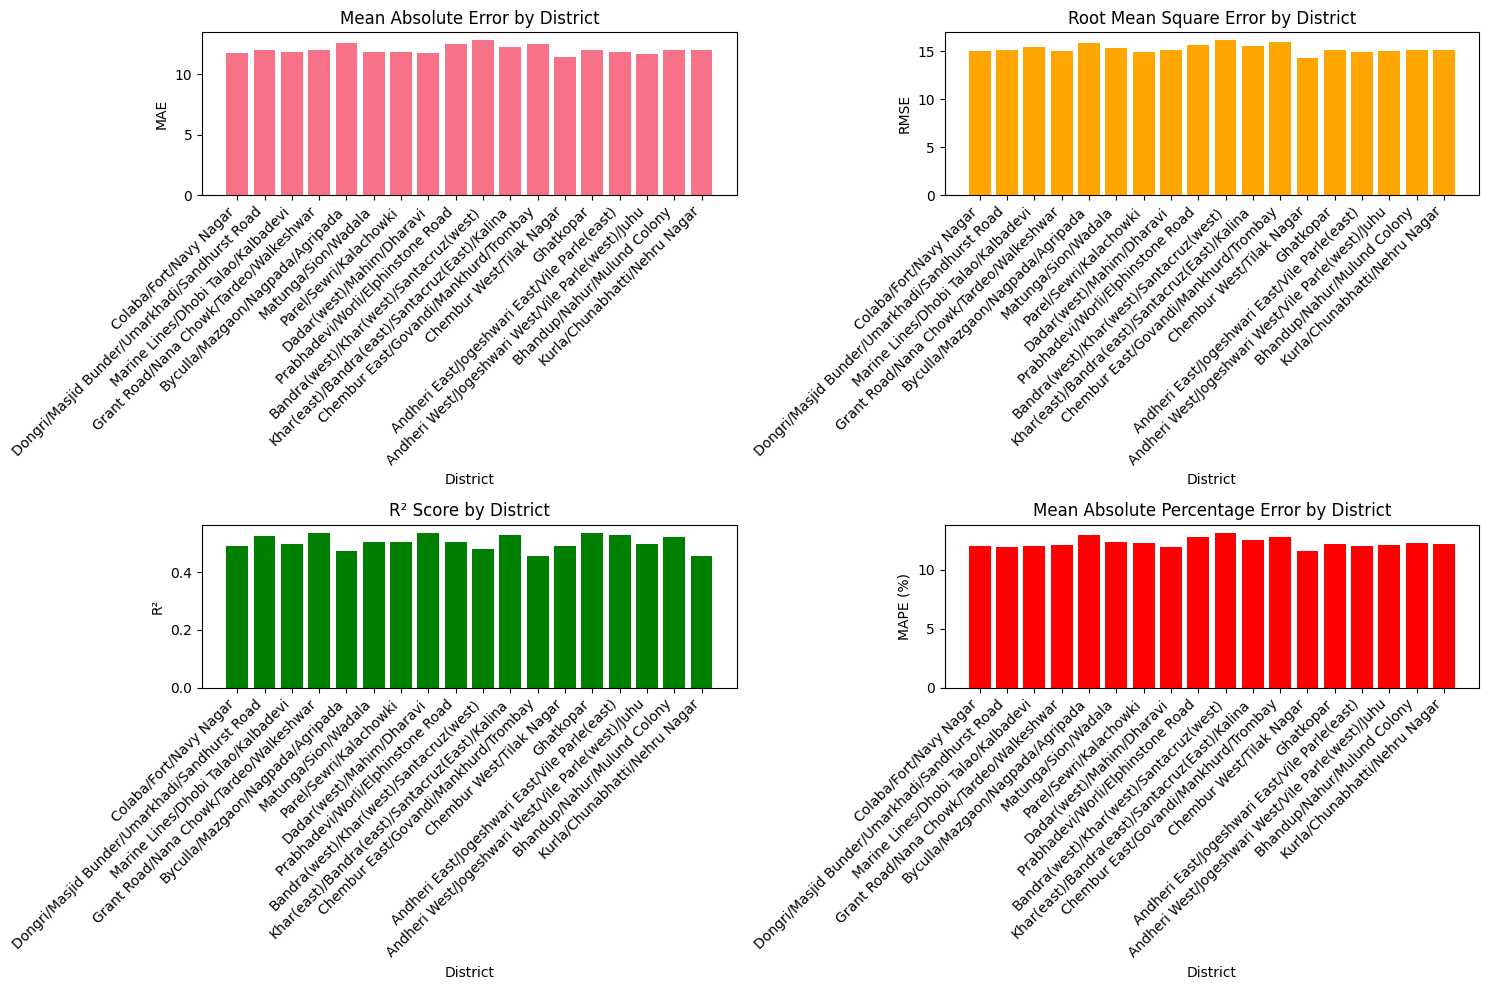


ANALYSIS COMPLETE!
✓ Prophet models trained for all districts
✓ 6-month forecasts generated
✓ Visualizations created for all indexes
✓ Performance metrics calculated
✓ Results exported to CSV

Key Insights:
- City-wide average daily waste: 2092
- Could not determine the highest generating district due to missing 'Total_Waste' data.
- Best model performance (R²): Ghatkopar


In [68]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

performance_metrics = []

for district in analysis_df['District'].unique():
    forecast = district_forecasts[district]

    # Get historical period (exclude future predictions)
    historical_forecast = forecast[forecast['ds'] < datetime.now()]

    # Get actual values from our synthetic historical data
    actual_data = historical_df[historical_df['district'] == district]

    # Merge actual and predicted values
    comparison = pd.merge(historical_forecast[['ds', 'yhat']],
                         actual_data[['ds', 'y']], on='ds')

    if len(comparison) > 0:
        mae = mean_absolute_error(comparison['y'], comparison['yhat'])
        rmse = np.sqrt(mean_squared_error(comparison['y'], comparison['yhat']))
        r2 = r2_score(comparison['y'], comparison['yhat'])
        mape = np.mean(np.abs((comparison['y'] - comparison['yhat']) / comparison['y'])) * 100

        performance_metrics.append({
            'District': district,
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2,
            'MAPE (%)': mape
        })

# Create performance DataFrame
performance_df = pd.DataFrame(performance_metrics)

print("MODEL PERFORMANCE METRICS:")
print("="*60)
print(performance_df.to_string(index=False, float_format='%.3f'))

# Visualize performance metrics
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# MAE by district
axes[0,0].bar(range(len(performance_df)), performance_df['MAE'])
axes[0,0].set_title('Mean Absolute Error by District')
axes[0,0].set_xlabel('District')
axes[0,0].set_ylabel('MAE')
axes[0,0].set_xticks(range(len(performance_df)))
axes[0,0].set_xticklabels(performance_df['District'], rotation=45, ha='right')

# RMSE by district
axes[0,1].bar(range(len(performance_df)), performance_df['RMSE'], color='orange')
axes[0,1].set_title('Root Mean Square Error by District')
axes[0,1].set_xlabel('District')
axes[0,1].set_ylabel('RMSE')
axes[0,1].set_xticks(range(len(performance_df)))
axes[0,1].set_xticklabels(performance_df['District'], rotation=45, ha='right')

# R² by district
axes[1,0].bar(range(len(performance_df)), performance_df['R²'], color='green')
axes[1,0].set_title('R² Score by District')
axes[1,0].set_xlabel('District')
axes[1,0].set_ylabel('R²')
axes[1,0].set_xticks(range(len(performance_df)))
axes[1,0].set_xticklabels(performance_df['District'], rotation=45, ha='right')

# MAPE by district
axes[1,1].bar(range(len(performance_df)), performance_df['MAPE (%)'], color='red')
axes[1,1].set_title('Mean Absolute Percentage Error by District')
axes[1,1].set_xlabel('District')
axes[1,1].set_ylabel('MAPE (%)')
axes[1,1].set_xticks(range(len(performance_df)))
axes[1,1].set_xticklabels(performance_df['District'], rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)
print("✓ Prophet models trained for all districts")
print("✓ 6-month forecasts generated")
print("✓ Visualizations created for all indexes")
print("✓ Performance metrics calculated")
print("✓ Results exported to CSV")
print("\nKey Insights:")
print(f"- City-wide average daily waste: {future_city_forecast['yhat'].mean():.0f}")

# Check if there are any non-null values in 'Total_Waste' before finding the max
if analysis_df['Total_Waste'].notna().any():
    highest_waste_district = analysis_df.loc[analysis_df['Total_Waste'].idxmax(), 'District']
    print(f"- Highest generating district: {highest_waste_district}")
else:
    print("- Could not determine the highest generating district due to missing 'Total_Waste' data.")

# Check if performance_df is not empty before finding the max R²
if not performance_df.empty and 'R²' in performance_df.columns:
    best_model_district = performance_df.loc[performance_df['R²'].idxmax(), 'District']
    print(f"- Best model performance (R²): {best_model_district}")
else:
    print("- Could not determine the best model performance due to missing performance data.")

print("="*80)